# Bisecting K-Means - Instacart (simple)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [7]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    bisecting_kmeans_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [8]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")
df_original = pd.read_csv("../../../simple_datasets/instacart_model_simple.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["user_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 206,209
Variables de clustering: 3


,recency,frequency,avg_basket_size
0,-0.286895,-0.070348,-0.578158
1,1.212334,0.316791,0.820566
2,-0.568000,0.138171,-0.236083
3,1.212334,-0.826933,-1.313020
4,-1.036509,-1.054508,0.139108


## Evaluación del número de clusters


In [9]:
resultados_bisecting = bisecting_kmeans_metrics(X)
display(resultados_bisecting)

,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos
0,2,0.325604,105945.774703,1.277899,408663.195518,0.194168
1,3,0.282786,87719.394917,1.286207,334251.045692,0.280339
2,4,0.284781,94084.294257,1.209433,261157.941386,0.424944
3,5,0.265854,84766.318378,1.158148,233946.813059,0.437830
4,6,0.258396,85109.325161,1.137532,201920.732769,0.416781
5,7,0.238855,83392.198369,1.152930,180542.145930,0.475022
6,8,0.232892,79252.740331,1.243066,167631.429253,0.497569
7,9,0.226259,75016.327226,1.283574,158200.449611,0.521256
8,10,0.231219,72420.830075,1.311221,148675.141189,0.533464


In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_bisecting,
    model_name="bisecting",
    dataset_name="instacart",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

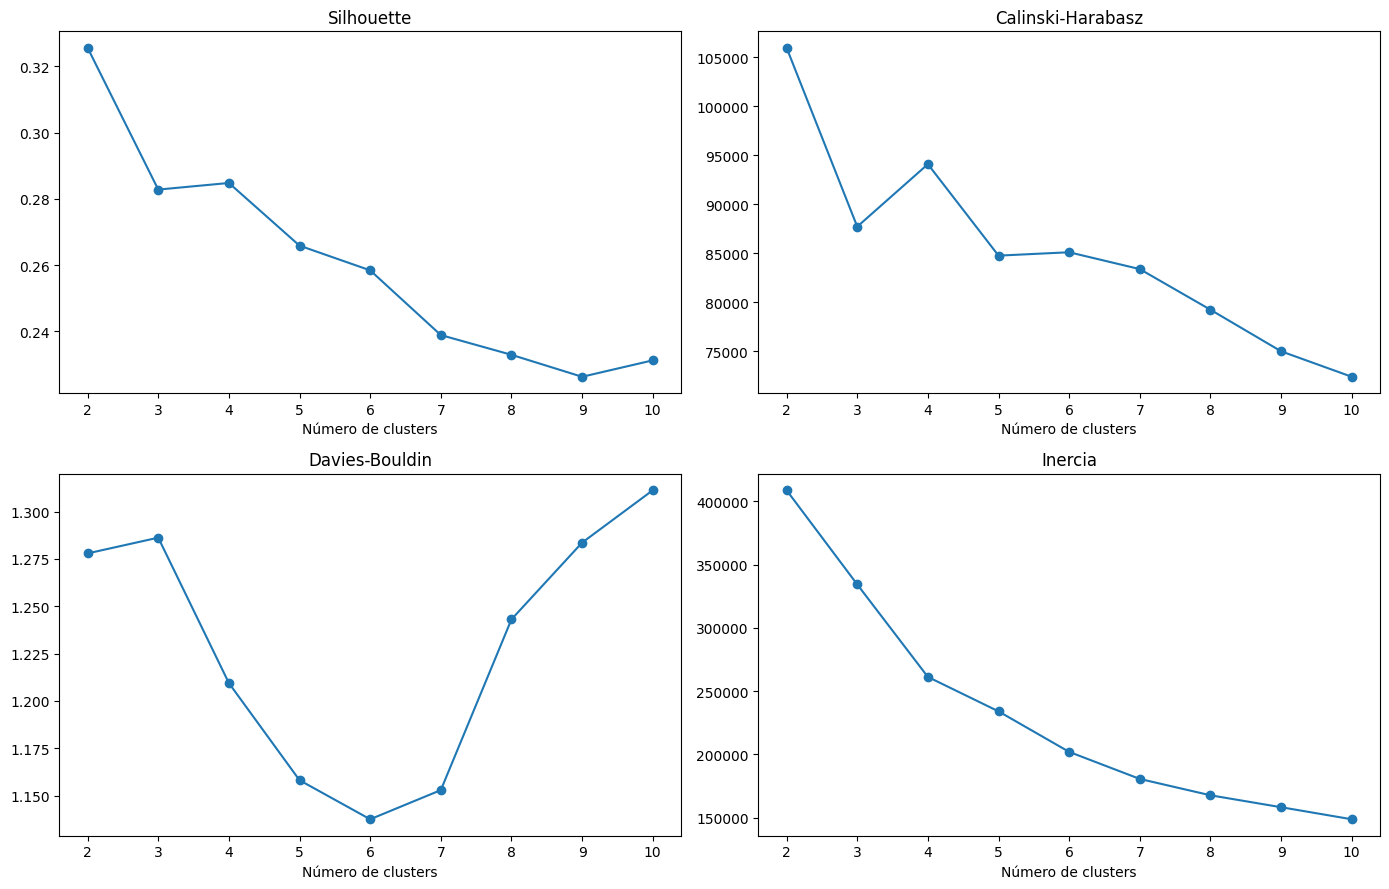

In [10]:
plot_clustering_metrics(
    resultados_bisecting,
    fourth_metric="inertia",
    fourth_title="Inercia",
)

## Ajuste final y perfil de los clusters


In [11]:
modelo, labels = fit_clustering_model(
    model_name="bisecting",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    100807
1    105402
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    48.89
1    51.11
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,26.548,8.171,9.411
1,7.989,22.686,10.468


- Cluster 0 - Clientes menos recientes y moderados (48,89%): presentan mayor recencia, baja frecuencia y cestas ligeramente menores.
- Cluster 1 - Clientes activos y frecuentes (51,11%): compran recientemente, realizan casi tres veces más pedidos y mantienen cestas algo mayores.

In [12]:
modelo, labels = fit_clustering_model(
    model_name="bisecting",
    k=4,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    60258
1    40549
2    52968
3    52434
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    29.22
1    19.66
2    25.69
3    25.43
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,26.995,8.527,12.828
1,25.883,7.643,4.334
2,7.645,8.635,10.455
3,8.337,36.880,10.482


- Cluster 0 - Clientes ocasionales de cesta grande (29,22%): tienen alta recencia y baja frecuencia, pero realizan cestas grandes.
- Cluster 1 - Clientes ocasionales de cesta pequeña (19,66%): también compran con poca frecuencia y llevan tiempo sin comprar, aunque sus cestas son las menores.
- Cluster 2 - Clientes recientes de actividad moderada (25,69%): presentan baja recencia y frecuencia moderada, con cestas de tamaño medio.
- Cluster 3 - Clientes frecuentes y activos (25,43%): destacan por una frecuencia muy elevada y baja recencia, manteniendo cestas medias.

In [13]:
modelo, labels = fit_clustering_model(
    model_name="bisecting",
    k=6,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    60258
1    40549
2    22249
3    30719
4    29360
5    23074
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    29.22
1    19.66
2    10.79
3    14.90
4    14.24
5    11.19
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,26.995,8.527,12.828
1,25.883,7.643,4.334
2,6.738,8.732,5.393
3,8.302,8.565,14.121
4,8.947,35.252,14.115
5,7.560,38.951,5.859


- Cluster 0 - Clientes ocasionales de cesta grande (29,22%): combinan alta recencia y baja frecuencia con cestas grandes.
- Cluster 1 - Clientes ocasionales de cesta pequeña (19,66%): presentan alta recencia, baja frecuencia y las cestas más pequeñas.
- Cluster 2 - Clientes recientes de cesta pequeña (10,79%): compran recientemente y con frecuencia moderada, pero forman cestas reducidas.
- Cluster 3 - Clientes recientes de cesta grande (14,90%): muestran baja recencia y frecuencia moderada, con cestas grandes.
- Cluster 4 - Clientes frecuentes de cesta grande (14,24%): compran muy a menudo y recientemente y forman cestas grandes.
- Cluster 5 - Clientes frecuentes de cesta pequeña (11,19%): presentan la mayor frecuencia y baja recencia, aunque realizan cestas relativamente pequeñas.